In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import pandas as pd
from matplotlib.ticker import MaxNLocator

In [3]:
if not os.path.exists('./plots'):
    os.makedirs('./plots')

In [4]:
def prepare_sample(pd_data, column_name):
    '''
    get the parameter list and age list of both male subjects and female subjects
    '''
    param_male = np.array(pd_data[column_name][pd_data['sex']==1])
    print('number of male subjects:', len(param_male))
    age_male = np.array(pd_data['age'][pd_data['sex']==1])
    param_female = np.array(pd_data[column_name][pd_data['sex']==2])
    print('number of female subjects:', len(param_female))
    age_female = np.array(pd_data['age'][pd_data['sex']==2])

    sorted_indices_male = np.argsort(age_male)
    age_male = age_male[sorted_indices_male]
    param_male = param_male[sorted_indices_male]

    sorted_indices_female = np.argsort(age_female)
    age_female = age_female[sorted_indices_female]
    param_female = param_female[sorted_indices_female]
    return param_male, age_male, param_female, age_female

In [5]:
def lowess_fit(x_sample, y_sample, frac=0.75, n_bootstrap = 1000):
    # frac: Fraction of data used for smoothing
    y_smoothed = lowess(y_sample, x_sample, frac=frac)[:, 1]
    # x_smoothed == x_sample
    bootstrap_samples = np.zeros((n_bootstrap, len(x_sample)))
    for i in range(n_bootstrap):
        indices = np.random.choice(range(len(x_sample)), len(x_sample), replace=True)
        x_resample = x_sample[indices]
        y_resample = y_sample[indices]
        bootstrap_samples[i, :] = lowess(y_resample, x_resample, frac=frac, xvals=x_sample)

    # Calculate confidence intervals
    lower_bound = np.percentile(bootstrap_samples, 2.5, axis=0)
    upper_bound = np.percentile(bootstrap_samples, 97.5, axis=0)

    return y_smoothed, lower_bound, upper_bound

## AV Curves for CN healthy subjects

In [6]:
param_file = './data/chinese_vascular_volume.csv'
param_data = pd.read_csv(param_file)
print(len(param_data))
param_data.head()

886


,av,COW,PCA,MCA,ACA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,14696.875,2257.000,1245.875,6312.75,1833.250,0,0.000,1.000,0.000,0,...,168.000,33.500,45.500,22.000,0.125,0.000,117.375,2898.125,88,1
1,13453.500,1476.125,1204.000,5490.25,2004.625,0,34.000,0.000,0.000,0,...,108.750,128.000,23.125,74.125,14.750,0.000,67.000,2861.375,84,1
2,16491.125,2219.000,1886.375,7574.00,2219.250,0,26.000,31.125,22.125,0,...,131.625,247.125,125.750,224.375,50.500,0.000,210.125,3256.625,77,1
3,11271.875,1096.750,1373.500,5340.00,1301.875,0,7.375,6.750,17.875,0,...,76.875,134.500,16.125,181.000,18.000,0.125,53.750,2598.500,42,2
4,16967.625,2918.750,1516.000,6773.75,1888.250,0,9.625,3.250,22.375,0,...,61.625,256.000,82.000,174.125,24.750,0.000,69.250,3510.750,85,1


#### whole-brain AV curve (CN healthy subjects)

In [8]:
## whole-brain AV
param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name='av')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)

number of male subjects: 424
number of female subjects: 462


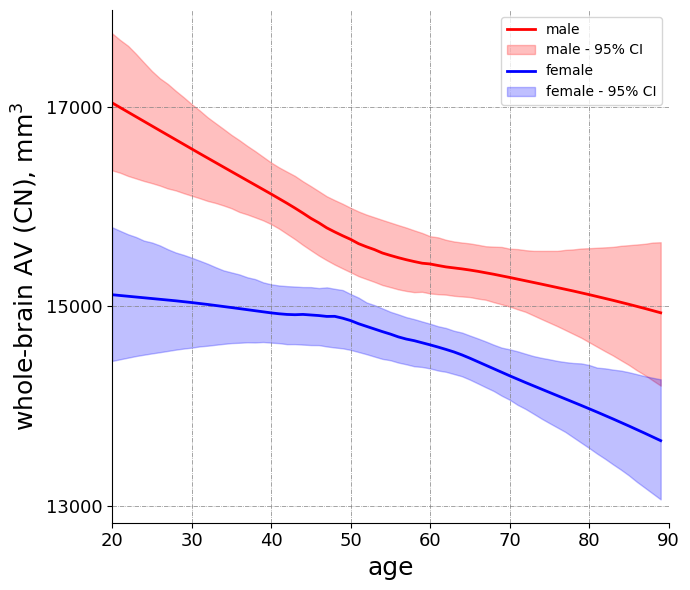

In [9]:
# curves for whole-brain AV
# Plot the the smoothed curve, and the confidence intervals 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')
ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain AV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([13000, 15000, 17000])
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_whole_AV.png', dpi=500, bbox_inches='tight')
plt.show()

#### AV curves in 4 typical brain regions (CN healthy subjects)

424
424
462
462
424
424
462
462
424
424
462
462
424
424
462
462


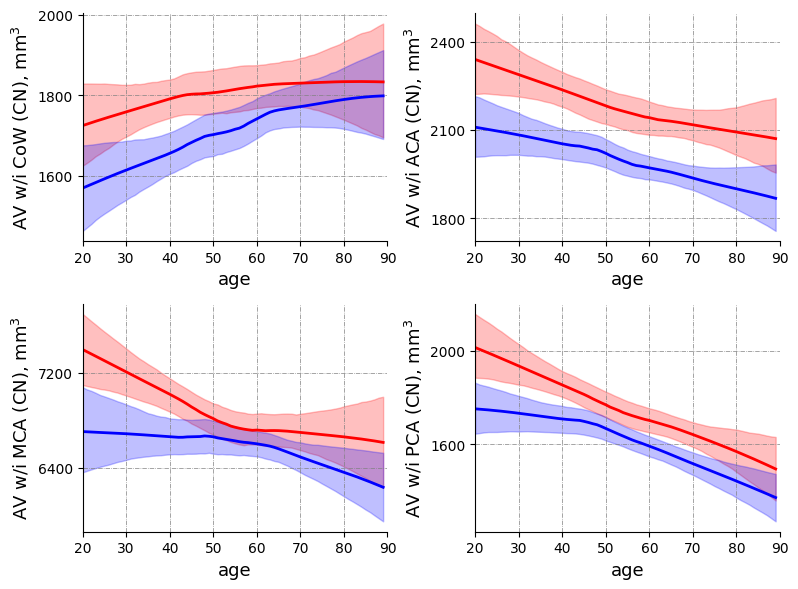

In [136]:
# curves for AV in 4 typical regions
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    frac = 0.75 # Fraction of data used for smoothing
    y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
    y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)
    ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
    ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
    ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('AV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_4R_AV.png', dpi=500, bbox_inches='tight')
plt.show()    

#### AV curves in brodmann regions (CN healthy subjects)

number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of female subjects: 462
number of male subjects: 424
number of f

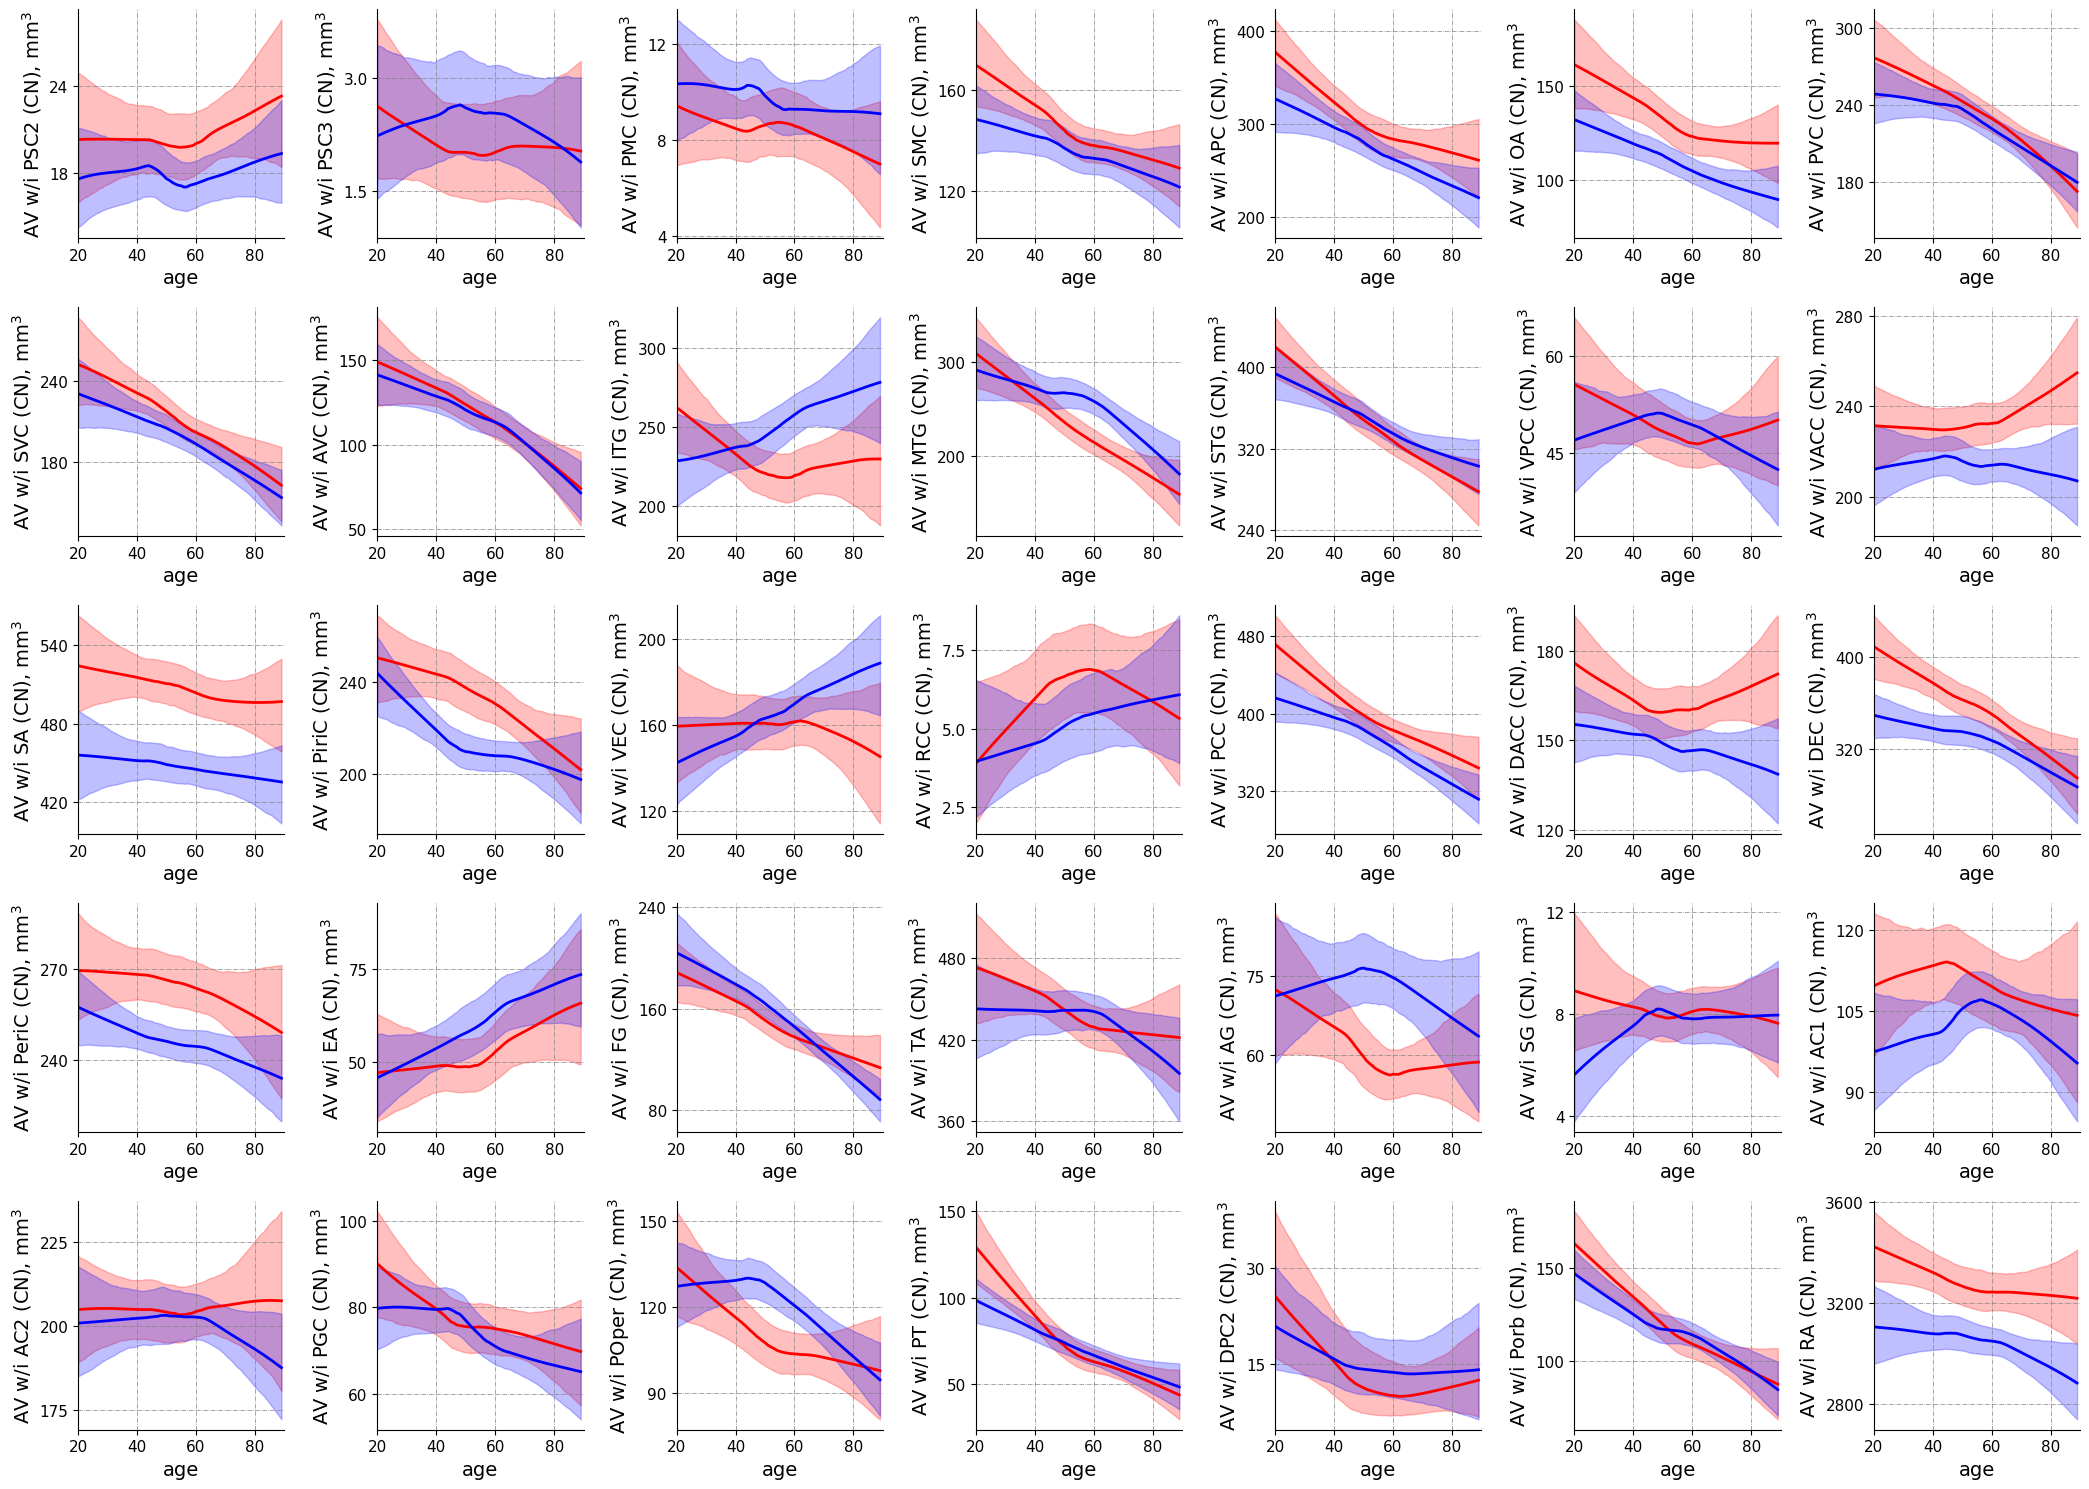

In [7]:
# curves for AV in brodmann areas
fig = plt.figure(figsize=(21, 15))

column_names = ['PSC2', 'PSC3', 'PMC', 'SMC',  'APC', 'OA', 
                'PVC', 'SVC', 'AVC', 'ITG', 'MTG', 'STG', 'VPCC',
                'VACC', 'SA', 'PiriC', 'VEC', 'RCC', 'PCC', 'DACC',	'DEC',
                'PeriC', 'EA', 'FG', 'TA', 'AG', 'SG', 'AC1', 'AC2', 'PGC',
                 'POper', 'PT', 'DPC2',	'Porb', 'RA']


for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(5, 7, idx+1)
    param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name=column_name)
    # Apply LOESS smoothing
    frac = 0.75 # Fraction of data used for smoothing
    y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
    y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)
    ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
    ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
    ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

    ax.set_xlabel('age', fontsize=14)
    ax.set_ylabel('AV w/i ' + column_name + ' (CN), mm$^3$', fontsize=14)
    ax.axes.tick_params(labelsize=11)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_brodmann_AV.png', dpi=500, bbox_inches='tight')
plt.show()    

## AV Curves for UK healthy subjects

In [5]:
param_file = './data/uk_vascular_volume_match.csv'

param_data = pd.read_csv(param_file)
print(len(param_data))
param_data = param_data.dropna()
print(len(param_data))
param_data.head()

858
816


,av,COW,ACA,MCA,PCA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,14451.750,1053.125,1990.125,6626.875,1890.875,37.250,63.625,58.75,81.250,0,...,68.875,78.750,138.125,299.000,367.875,70.750,310.125,2156.500,35.800137,2
1,16098.875,1423.875,2800.250,7404.875,1513.375,22.125,105.125,41.00,49.500,0,...,57.625,72.000,74.750,312.000,325.750,109.500,342.500,2822.125,38.781656,1
2,18868.750,1192.875,2646.750,8705.375,2921.000,11.125,90.375,73.00,71.125,0,...,74.750,147.000,99.875,255.250,368.875,56.250,345.000,3214.625,46.710472,1
3,14517.750,1076.125,1939.000,6533.000,1679.250,6.250,60.750,34.50,49.125,0,...,61.250,167.500,89.500,230.250,271.250,49.875,242.250,2465.750,24.284736,1
4,13558.750,1319.625,1913.750,5682.625,1740.250,11.875,86.125,93.00,80.375,0,...,47.125,157.375,136.500,160.125,62.250,32.500,224.000,2426.375,55.167693,1


#### whole-brain AV curve (UK healthy subjects)

In [15]:
## whole-brain AV
param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name='av')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)

407
407
409
409


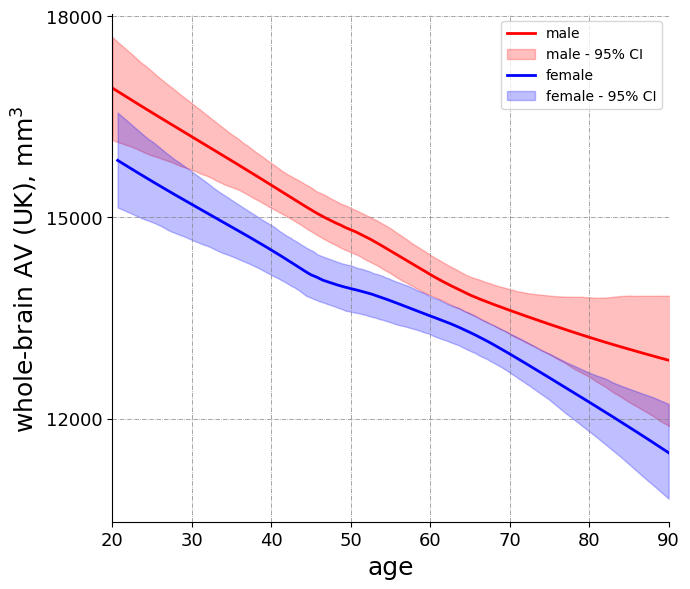

In [16]:
# curves for whole-brain AV
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6) )
ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')
ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain AV (UK), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/UK_health_whole_AV.png', dpi=500, bbox_inches='tight')
plt.show()

#### AV curves in 4 typical brain regions (UK healthy subjects)

407
407
409
409
407
407
409
409
407
407
409
409
407
407
409
409


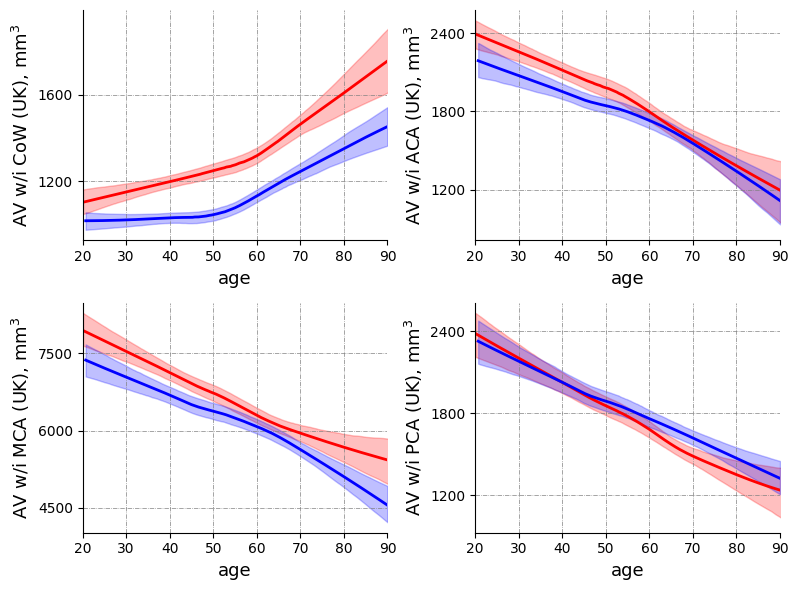

In [17]:
# curves for AV in 4 typical regions
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    frac = 0.75 # Fraction of data used for smoothing
    y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
    y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)
    ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
    ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
    ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('AV w/i ' + column_name + ' (UK), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/UK_health_4R_AV.png', dpi=500, bbox_inches='tight')
plt.show()    

#### AV curves in brodmann regions (UK healthy subjects)

407
407
409
409
407
407
409
409
407
407
409
409
407
407
409
409
407
407
409
409
407
407
409
409
407
407
409
409


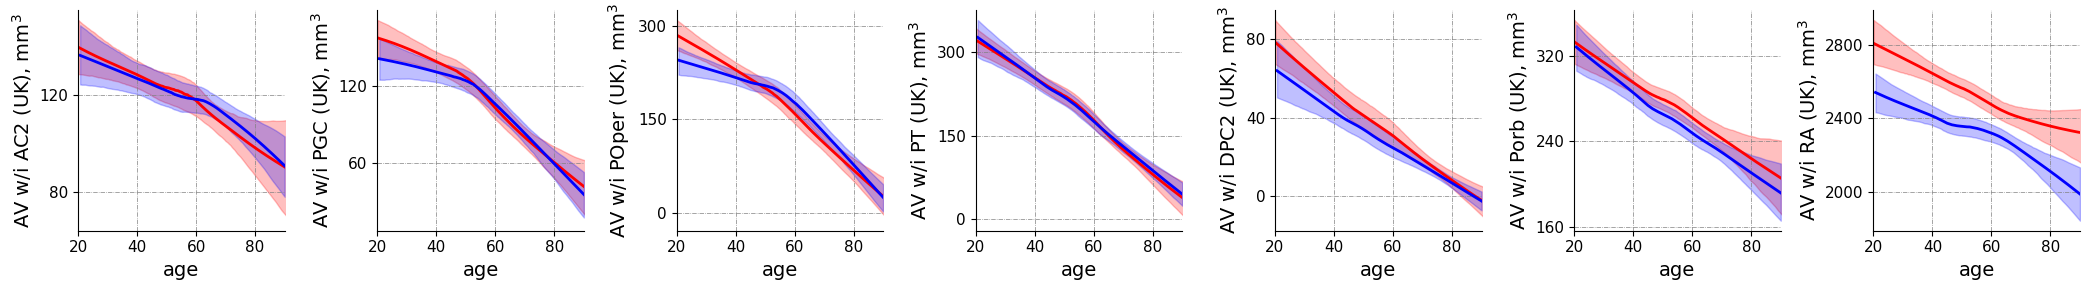

In [22]:
# curves for AV in brodmann areas
fig = plt.figure(figsize=(21, 15))
column_names = ['PSC2', 'PSC3', 'PMC', 'SMC',  'APC', 'OA', 
                'PVC', 'SVC', 'AVC', 'ITG', 'MTG', 'STG', 'VPCC',
                'VACC', 'SA', 'PiriC', 'VEC', 'RCC', 'PCC', 'DACC',	'DEC',
                'PeriC', 'EA', 'FG', 'TA', 'AG', 'SG', 'AC1', 'AC2', 'PGC',
                 'POper', 'PT', 'DPC2',	'Porb', 'RA']


for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(5, 7, idx+1)
    param_male, age_male, param_female, age_female = prepare_sample(param_data, column_name=column_name)
    # Apply LOESS smoothing
    frac = 0.75 # Fraction of data used for smoothing
    y_smoothed_male, lower_bound_male, upper_bound_male = lowess_fit(age_male, param_male, frac)
    y_smoothed_female, lower_bound_female, upper_bound_female = lowess_fit(age_female, param_female, frac)
    ax.plot(age_male, y_smoothed_male, label='male', color='red', linewidth=2)
    ax.fill_between(age_male, lower_bound_male, upper_bound_male, color='red', alpha=0.25, label='male - 95% CI')

    ax.plot(age_female, y_smoothed_female, label='female', color='blue', linewidth=2)
    ax.fill_between(age_female, lower_bound_female, upper_bound_female, color='blue', alpha=0.25, label='female - 95% CI')

    ax.set_xlabel('age', fontsize=14)
    ax.set_ylabel('AV w/i ' + column_name + ' (UK), mm$^3$', fontsize=14)
    ax.axes.tick_params(labelsize=11)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/UK_health_brodmann_AV.png', dpi=500, bbox_inches='tight')
plt.show()  